# Import Toolekit

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import joblib




In [90]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [91]:
df = pd.read_csv('../assets/car-price-prediction-linear-regression/car_details_v4.csv')
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [92]:
df.shape

(2059, 20)

# Preprocessing

In [93]:
df.columns.tolist()

['Make',
 'Model',
 'Price',
 'Year',
 'Kilometer',
 'Fuel Type',
 'Transmission',
 'Location',
 'Color',
 'Owner',
 'Seller Type',
 'Engine',
 'Max Power',
 'Max Torque',
 'Drivetrain',
 'Length',
 'Width',
 'Height',
 'Seating Capacity',
 'Fuel Tank Capacity']

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null   float64
 16  Width            

In [95]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [96]:
seat_Price = (
    df.groupby('Seating Capacity')['Price']
    .agg(['mean','median', 'count'])
    .sort_index()
)

seat_Price

,mean,median,count
Seating Capacity,,,
2.0,1.354286e+07,9500000.0,7
4.0,4.702809e+06,1875000.0,42
5.0,1.506851e+06,725000.0,1615
6.0,2.419956e+06,1850000.0,23
7.0,2.226121e+06,1500000.0,273
8.0,1.004314e+06,875000.0,35


<Axes: title={'center': 'Price'}, xlabel='Seating Capacity'>

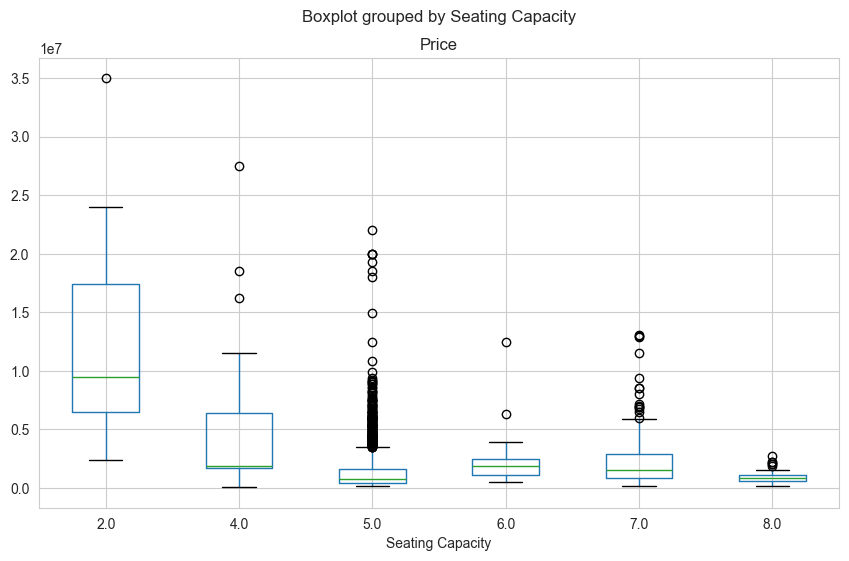

In [97]:
df.boxplot(column='Price', by='Seating Capacity')

In [98]:
Drivetrain_Price = (
    df.groupby('Drivetrain')['Price']
    .agg(['mean','median', 'count'])
    .sort_index()
)

Drivetrain_Price

,mean,median,count
Drivetrain,,,
AWD,4.292919e+06,3450000.0,272
FWD,9.011127e+05,643500.0,1330
RWD,3.153190e+06,2225000.0,321


In [99]:
df['Owner'].value_counts()

Owner
First               1619
Second               373
Third                 42
UnRegistered Car      21
Fourth                 3
4 or More              1
Name: count, dtype: int64

In [100]:
Owner_Price = (
    df.groupby('Owner')['Price']
    .agg(['mean','median', 'count'])
    .sort_index(ascending=False)
)

Owner_Price

,mean,median,count
Owner,,,
UnRegistered Car,5.285333e+06,5200000.0,21
Third,1.981929e+06,399500.0,42
Second,1.438051e+06,775000.0,373
Fourth,1.633333e+05,160000.0,3
First,1.714159e+06,849000.0,1619
4 or More,1.200000e+05,120000.0,1


In [101]:
Owner_SeatingCapacity_Price = (
    df.groupby(['Seating Capacity', 'Owner'])['Price']
    .agg(['mean','median', 'count'])
    .sort_index(ascending=False)
)

Owner_SeatingCapacity_Price

mean      median  count
Seating Capacity Owner                                            
8.0              UnRegistered Car  5.750000e+05    575000.0      1
                 Third             6.163333e+05    625000.0      3
                 Second            6.657143e+05    675000.0      7
                 Fourth            1.600000e+05    160000.0      1
                 First             1.213348e+06    951000.0     23
7.0              Third             5.995000e+05    599500.0      2
                 Second            1.682516e+06   1290000.0     64
                 Fourth            2.100000e+05    210000.0      1
                 First             2.420587e+06   1750000.0    206
6.0              Second            1.855000e+06   1850000.0      5
                 First             2.576889e+06   1712500.0     18
5.0              UnRegistered Car  5.453722e+06   4750000.0     18
                 Third             2.303800e+06    399500.0     30
                 Second            1.253634e+06    640000.0    265
                 Fourth            1.200000e+05    120000.0      1
                 First             1.487562e+06    732500.0   1300
                 4 or More         1.200000e+05    120000.0      1
4.0              UnRegistered Car  5.200000e+06   5200000.0      1
                 Third             4.675000e+06   4675000.0      2
                 Second            9.200000e+06   5400000.0      5
                 First             4.028471e+06   1857499.5     34
2.0              Second            4.000000e+06   4000000.0      1
                 First             1.513333e+07  10200000.0      6

In [102]:
Engine_Price = (
    df.groupby('Engine')['Price']
    .agg(['mean','median', 'count'])
    .sort_index()
)

Engine_Price

,mean,median,count
Engine,,,
1047 cc,434500.000000,434500.0,2
1061 cc,170600.000000,160000.0,5
1086 cc,306814.629630,250000.0,27
1120 cc,410333.333333,420500.0,6
1186 cc,418749.500000,439999.5,4
...,...,...,...
814 cc,261153.846154,250000.0,13
936 cc,229999.000000,229999.0,1
995 cc,190000.000000,190000.0,1


In [103]:
maxPower_Price = (
    df.groupby('Max Power')['Price']
    .agg(['mean','median', 'count'])
    .sort_index()
)

maxPower_Price

,mean,median,count
Max Power,,,
100 bhp @ 3600 rpm,1.013333e+06,1000000.0,3
100 bhp @ 3750 rpm,6.162856e+05,630000.0,7
100@5500,3.100000e+05,310000.0,1
101 bhp @ 3600 rpm,9.247498e+05,921999.5,4
102@5500,2.550000e+05,255000.0,2
...,...,...,...
98 bhp @ 6000 rpm,3.150000e+05,315000.0,1
99 bhp @ 3600 rpm,5.920417e+05,545000.0,24
99 bhp @ 3750 rpm,6.368462e+05,620000.0,13


In [104]:
Power_units = (df['Max Power']
    .astype(str)
    .str.replace(r"[0-9\.]", "", regex=True)
    .str.strip()
    .unique())

print("Unique units in 'Max Power':", Power_units)

Unique units in 'Max Power': <StringArray>
['bhp @  rpm', nan, '@', 'bhp @']
Length: 4, dtype: str


In [105]:
Torque_units = (df['Max Torque']
    .astype(str)
    .str.replace(r"[0-9\.]", "", regex=True)
    .str.strip()
    .unique())

print("Unique units in 'Max Torque':", Torque_units)

Unique units in 'Max Torque': <StringArray>
['Nm @  rpm', nan, '@']
Length: 3, dtype: str


In [106]:
Engine_units = (df['Engine']
    .astype(str)
    .str.replace(r"[0-9\.]", "", regex=True)
    .str.strip()
    .unique())

print("Unique units in 'Engine':", Engine_units)

Unique units in 'Engine': <StringArray>
['cc', nan]
Length: 2, dtype: str


In [107]:
import re
def extract_numeric_value(val : str) -> float:
    if pd.isnull(val):
        return np.nan
    val = str(val).strip()
    val = re.findall(r'\d+\.?\d*', val)
    if val:
        return float(val[0])
    return np.nan


In [108]:
extract_numeric_value('100 bhp @ 3600 rpm')

100.0

In [109]:
def categorize_seats(seats :str) -> str:
    if pd.isnull(seats):
        return np.nan
    elif seats <= 2:
        return 'Sports'
    elif seats == 4:
        return 'Coupe'
    elif seats == 5:
        return 'Standard'
    elif seats in [6, 7]:
        return 'Large_Family'
    elif seats >= 8:
        return 'utility'
    else:
        return 'Other'

In [110]:
cleaned_df = df.copy()

cleaned_df['Seating Capacity'] = cleaned_df['Seating Capacity'].apply(categorize_seats)
cleaned_df['Engine'] = cleaned_df['Engine'].apply(extract_numeric_value)
cleaned_df['Max Power'] = cleaned_df['Max Power'].apply(extract_numeric_value)
cleaned_df['Max Torque'] = cleaned_df['Max Torque'].apply(extract_numeric_value)
 
cleaned_df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,87.0,109.0000,FWD,3990.0,1680.0,1505.0,Standard,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,74.0,190.0000,FWD,3995.0,1695.0,1555.0,Standard,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,79.0,112.7619,FWD,3585.0,1595.0,1550.0,Standard,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,82.0,113.0000,FWD,3995.0,1745.0,1510.0,Standard,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,148.0,343.0000,RWD,4735.0,1830.0,1795.0,Large_Family,55.0


In [111]:
imputer_median = SimpleImputer(strategy='median')
imputer_mode = SimpleImputer(strategy='most_frequent')

numeric_cols = cleaned_df.select_dtypes(include=[np.number]).columns


cleaned_df[numeric_cols] = imputer_median.fit_transform(cleaned_df[numeric_cols])
cleaned_df[cleaned_df.columns.difference(numeric_cols)] = imputer_mode.fit_transform(cleaned_df[cleaned_df.columns.difference(numeric_cols)])


print("NaN values after imputation:")
print(cleaned_df.isnull().sum())


NaN values after imputation:
Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64


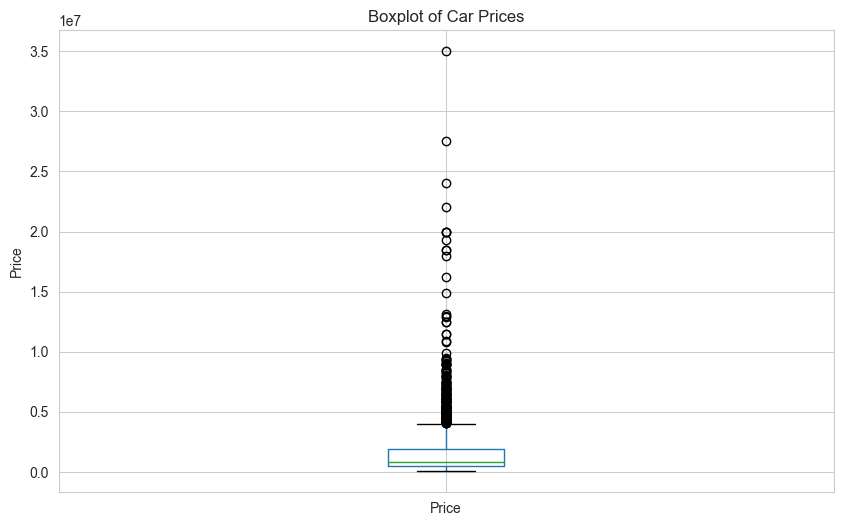

Price statistics:
count    2.059000e+03
mean     1.702992e+06
std      2.419881e+06
min      4.900000e+04
25%      4.849990e+05
50%      8.250000e+05
75%      1.925000e+06
max      3.500000e+07
Name: Price, dtype: float64


In [112]:
cleaned_df.boxplot(column='Price')
plt.title('Boxplot of Car Prices')
plt.ylabel('Price')
plt.show()
print("Price statistics:")
print(cleaned_df['Price'].describe())

In [113]:
Q1 = cleaned_df['Price'].quantile(0.25)
Q3 = cleaned_df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

Lower bound for outliers: -1675002.5
Upper bound for outliers: 4085001.5


In [114]:
before_outliers = cleaned_df.shape[0]
cleaned_df = cleaned_df[(cleaned_df['Price'] >= max(0, lower_bound)) & (cleaned_df['Price'] <= upper_bound)]
after_outliers = cleaned_df.shape[0]
print(f"Number of outliers removed: {before_outliers - after_outliers}")


Number of outliers removed: 215


In [115]:
cleaned_df.info()

<class 'pandas.DataFrame'>
Index: 1844 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1844 non-null   str    
 1   Model               1844 non-null   str    
 2   Price               1844 non-null   float64
 3   Year                1844 non-null   float64
 4   Kilometer           1844 non-null   float64
 5   Fuel Type           1844 non-null   str    
 6   Transmission        1844 non-null   str    
 7   Location            1844 non-null   str    
 8   Color               1844 non-null   str    
 9   Owner               1844 non-null   str    
 10  Seller Type         1844 non-null   str    
 11  Engine              1844 non-null   float64
 12  Max Power           1844 non-null   float64
 13  Max Torque          1844 non-null   float64
 14  Drivetrain          1844 non-null   str    
 15  Length              1844 non-null   float64
 16  Width               18

# Pipeline

In [116]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols.difference(['Price'])),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False),
            cleaned_df.columns.difference(numeric_cols).difference(['Price'])
        )
    ],
    remainder='drop'
)

def build_model_LinearRegression():
    model_LinearRegression = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    return model_LinearRegression

def build_model_Ridge():
    model_Ridge = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=10.0))
    ])
    return model_Ridge

In [117]:
x = cleaned_df.drop('Price', axis=1)
y = cleaned_df['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model_LinearRegression = build_model_LinearRegression()


In [118]:
model_LinearRegression.fit(x_train, y_train)
y_pred_train = model_LinearRegression.predict(x_train)
y_pred_test = model_LinearRegression.predict(x_test)
print("Model trained successfully.")

Model trained successfully.


c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [119]:
print("Training set R² score:", r2_score(y_train, y_pred_train))
print("Test set R² score:", r2_score(y_test, y_pred_test))
print("Test set Mean Absolute Error:", mean_absolute_error(y_test, y_pred_test))
print("Test set Mean Squared Error:", mean_squared_error(y_test, y_pred_test))

Training set R² score: 0.9843526623318599
Test set R² score: 0.48238291319937776
Test set Mean Absolute Error: 375111.79183395253
Test set Mean Squared Error: 383606442440.27454


In [120]:
overfitting_threshold = 0.1
overfitting_metric = r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)

if (overfitting_metric) > overfitting_threshold:
    print("Warning: The model may be overfitting the training data.")
else:
    print(f"Good generalization performance. R² difference: {overfitting_metric:.3f}")

In [121]:
model_Ridge = build_model_Ridge()

model_Ridge.fit(x_train, y_train)
y_pred_train = model_Ridge.predict(x_train)
y_pred_test = model_Ridge.predict(x_test)
print("Ridge Model trained successfully.")



Ridge Model trained successfully.


c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [122]:
print("Training set R² score:", r2_score(y_train, y_pred_train))
print("Test set R² score:", r2_score(y_test, y_pred_test))
print("Test set Mean Absolute Error:", mean_absolute_error(y_test, y_pred_test))
print("Test set Mean Squared Error:", mean_squared_error(y_test, y_pred_test))

Training set R² score: 0.8706296305027057
Test set R² score: 0.7828859254406911
Test set Mean Absolute Error: 255833.25582441283
Test set Mean Squared Error: 160903416578.0728


In [123]:
overfitting_threshold = 0.1
overfitting_metric = r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)

if (overfitting_metric) > overfitting_threshold:
    print("Warning: The model may be overfitting the training data.")
else:
    print(f"Good generalization performance. R² difference: {overfitting_metric:.3f}")

Good generalization performance. R² difference: 0.088


c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


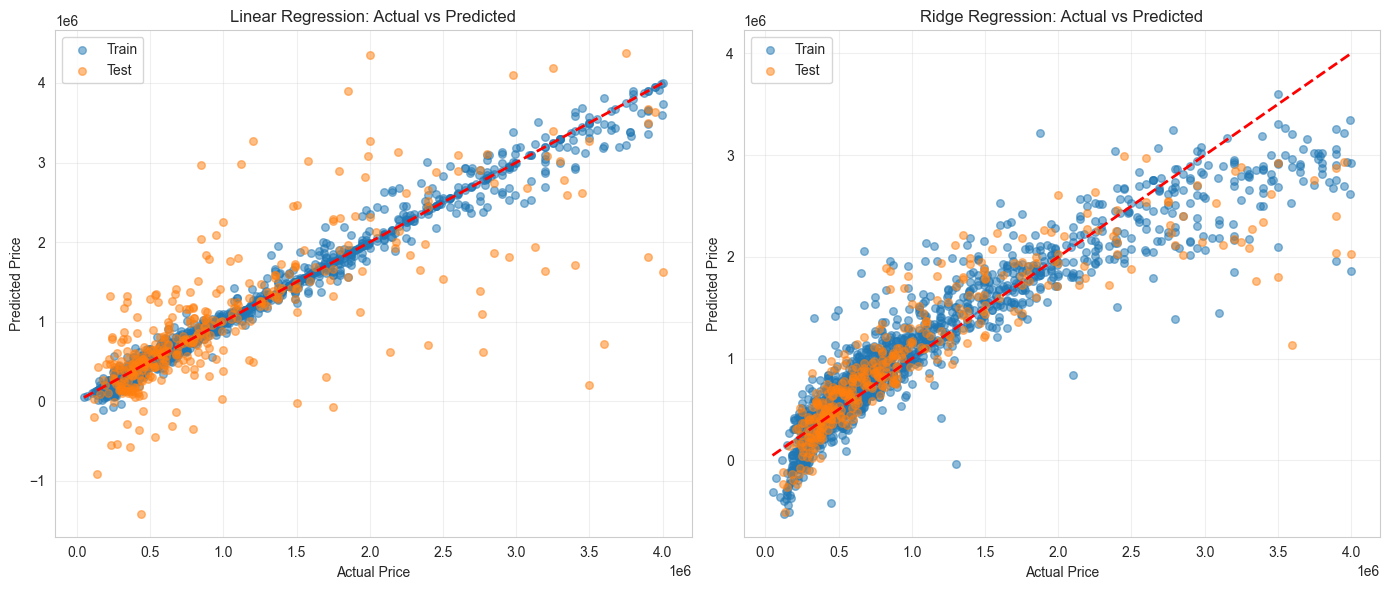

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
y_pred_train_lr = model_LinearRegression.predict(x_train)
y_pred_test_lr = model_LinearRegression.predict(x_test)

axes[0].scatter(y_train, y_pred_train_lr, alpha=0.5, label='Train', s=30)
axes[0].scatter(y_test, y_pred_test_lr, alpha=0.5, label='Test', s=30)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ridge Regression
y_pred_train_ridge = model_Ridge.predict(x_train)
y_pred_test_ridge = model_Ridge.predict(x_test)

axes[1].scatter(y_train, y_pred_train_ridge, alpha=0.5, label='Train', s=30)
axes[1].scatter(y_test, y_pred_test_ridge, alpha=0.5, label='Test', s=30)
axes[1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Ridge Regression: Actual vs Predicted')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Saving the model 

In [124]:
joblib.dump(model_LinearRegression, 'linear_regression_model.pkl')
joblib.dump(model_Ridge, 'ridge_regression_model.pkl')

['ridge_regression_model.pkl']